# Lab: Decision Boundary con 2 feature usando LogisticRegression

Questo notebook utilizza:
- 6 esempi di training
- 2 feature

Obiettivo:
capire come la regressione logistica costruisce una decision boundary.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline


## Dataset


In [2]:
X = np.array([
    [0.5, 1.5],
    [1.0, 1.0],
    [1.5, 0.5],
    [3.0, 0.5],
    [2.0, 2.0],
    [1.0, 2.5],
])

y = np.array([0,0,0,1,1,1])

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (6, 2)
Shape y: (6,)


## Visualizzazione dati
le etichette y=1 sono le crocette rosse e quelle con con y=0 sono le crocette blu

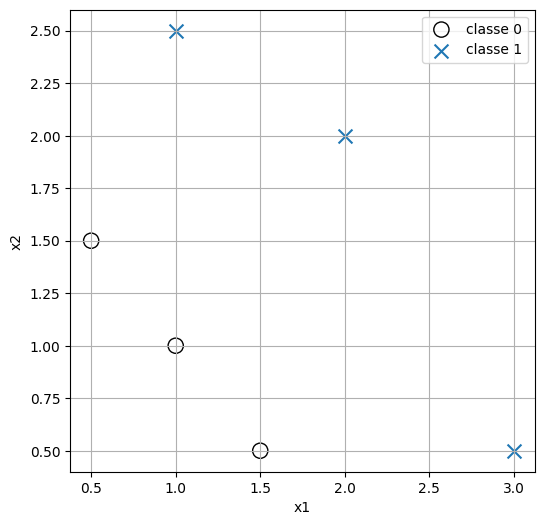

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(X[y==0][:,0], X[y==0][:,1],
            s=120, facecolors="none", edgecolors="black", label="classe 0")

plt.scatter(X[y==1][:,0], X[y==1][:,1],
            s=100, marker="x", label="classe 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


## Training modello


In [4]:
model = LogisticRegression()
model.fit(X,y)

w1 = model.coef_[0][0]
w2 = model.coef_[0][1]
b = model.intercept_[0]

print("w1:", w1)
print("w2:", w2)
print("b:", b)


w1: 0.9041134943596743
w2: 0.7358754294504456
b: -2.3337163116769677


## Decision boundary


### Da equazione a retta: perché la decision boundary è una linea

La regressione logistica (con 2 feature) calcola uno **score** lineare:

\[
z = w_1 * x_1 + w_2 * x_2 + b
\]

La regola di classificazione standard usa soglia 0.5 sulle probabilità.  
Con la sigmoide vale che **P = 0.5 ⇔ z = 0**, quindi la **decision boundary** è l’insieme dei punti per cui:

\[
w_1 * x_1 + w_2 * x_2 + b = 0
\]

Questa è l’equazione di una **retta** nel piano \((x_1, x_2)\).

Se vogliamo disegnarla come “x₂ in funzione di x₁”, isoliamo \(x_2\):

\[
x_2 = -(w_1* x_1 + b)/w_2
\]

Quindi:
- scegliamo una griglia di valori di \(x_1\),
- calcoliamo i corrispondenti \(x_2\) con la formula sopra,
- tracciamo la retta sul grafico.


In [5]:
# Mostriamo la formula numerica della decision boundary:
# w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1*x1 + b)/w2

print("Equazione decision boundary: w1*x1 + w2*x2 + b = 0")
print(f"Valori stimati: w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")
print("Forma esplicita:")
print(f"x2 = -({w1:.4f}*x1 + ({b:.4f})) / ({w2:.4f})")


Equazione decision boundary: w1*x1 + w2*x2 + b = 0
Valori stimati: w1=0.9041, w2=0.7359, b=-2.3337
Forma esplicita:
x2 = -(0.9041*x1 + (-2.3337)) / (0.7359)


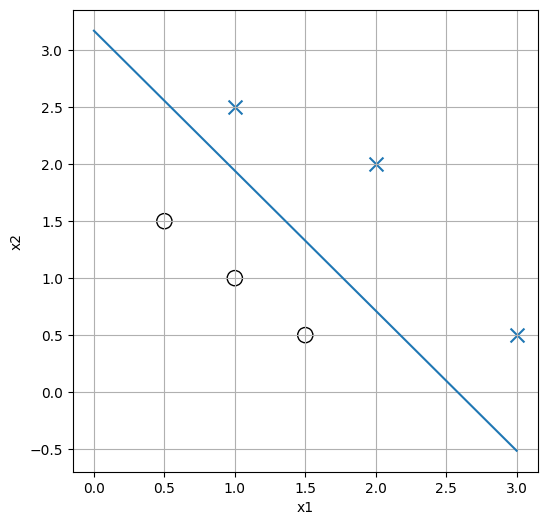

In [9]:
x1 = np.linspace(0,3,100)
x2 = -(w1*x1 + b)/w2

plt.figure(figsize=(6,6))

plt.scatter(X[y==0][:,0], X[y==0][:,1],
            s=120, facecolors="none", edgecolors="black")

plt.scatter(X[y==1][:,0], X[y==1][:,1],
            s=100, marker="x")

plt.plot(x1,x2)

plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()


## Predizioni


In [7]:
y_pred = model.predict(X)

print("y_true:", y)
print("y_pred:", y_pred)

print("accuracy:", accuracy_score(y,y_pred))

print("confusion matrix:")
print(confusion_matrix(y,y_pred))


y_true: [0 0 0 1 1 1]
y_pred: [0 0 0 1 1 1]
accuracy: 1.0
confusion matrix:
[[3 0]
 [0 3]]


Esercizio: Aggiungi almeno 2 ulteoriori punti e valuta come cambia il decision boundary, la accuratezza e la matrice di confusione